In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/kaggle/input/datasets/hemanthganeshvilluri/traffic-demand-hackathon/train.csv")
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [4]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


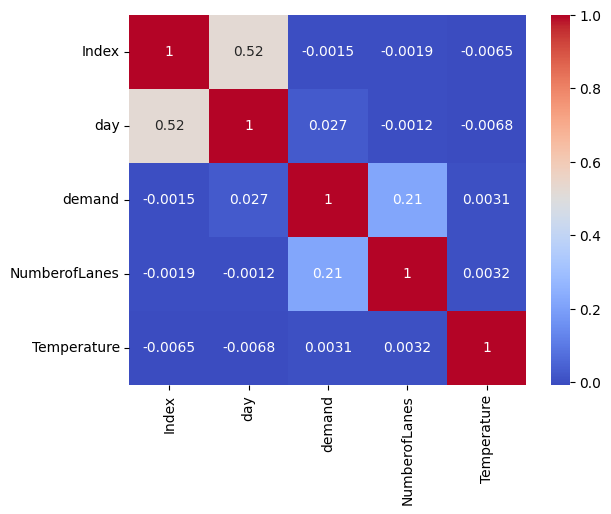

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [6]:
df['RoadType'].unique()

array([nan, 'Residential', 'Street', 'Highway'], dtype=object)

In [7]:
df['day'].value_counts()

day
48    69427
49     7872
Name: count, dtype: int64

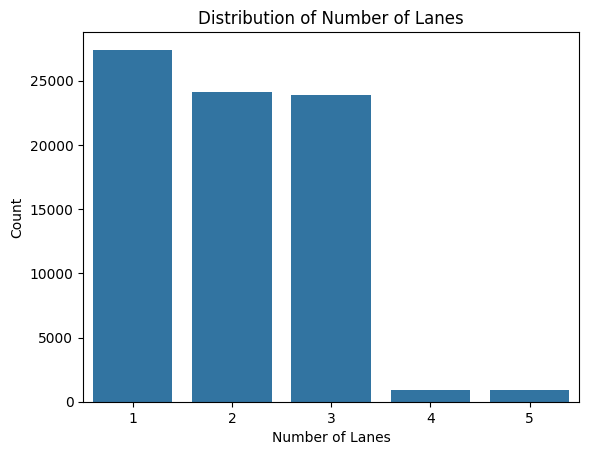

In [8]:
sns.countplot(x = 'NumberofLanes', data = df)
plt.title('Distribution of Number of Lanes')
plt.xlabel('Number of Lanes')
plt.ylabel('Count')
plt.show()

In [9]:
x = df.drop(['Index', 'demand'],axis = 1)
y = df['demand']

In [10]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer, StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor

In [12]:
def engineer_features(df):
    df2 = df.copy()
    df2[['hour', 'minute']] = (
        df2['timestamp']
        .str.split(':', expand=True)
        .astype(int)
    )

    df2['total_minutes'] = (
        df2['hour'] * 60 +
        df2['minute']
    )

    df2['time_sin'] = np.sin(
        2 * np.pi * df2['total_minutes'] / 1440
    )

    df2['time_cos'] = np.cos(
        2 * np.pi * df2['total_minutes'] / 1440
    )

    df2['time_slot'] = (
        df2['hour'] * 4 +
        df2['minute'] // 15
    )

    df2['is_morning_peak'] = (
        (df2['hour'] >= 7) &
        (df2['hour'] <= 10)
    ).astype(int)

    df2['is_evening_peak'] = (
        (df2['hour'] >= 16) &
        (df2['hour'] <= 20)
    ).astype(int)

    df2['day_of_week'] = df2['day'] % 7

    df2['is_weekend'] = (
        df2['day_of_week']
        .isin([5, 6])
    ).astype(int)

    df2['geo_3'] = df2['geohash'].str[:3]
    df2['geo_4'] = df2['geohash'].str[:4]
    df2['geo_5'] = df2['geohash'].str[:5]

    for i in range(6):
        df2[f'geo_char_{i}'] = (
            df2['geohash']
            .str[i]
        )
        
    df2['road_type_missing'] = (
        df2['RoadType']
        .isna()
        .astype(int)
    )

    df2['temp_missing'] = (
        df2['Temperature']
        .isna()
        .astype(int)
    )

    df2['geo_road'] = (
        df2['geo_4'].astype(str)
        + '_'
        + df2['RoadType'].astype(str)
    )

    df2['geo_weather'] = (
        df2['geo_4'].astype(str)
        + '_'
        + df2['Weather'].astype(str)
    )

    df2['lane_vehicle_interaction'] = (
        df2['NumberofLanes']
        *
        (df2['LargeVehicles'] == 'Allowed').astype(int)
    )

    return df2

In [13]:
feat_eng = FunctionTransformer(engineer_features)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [16]:
x_train.shape

(61839, 9)

In [17]:
nums = [
    'day', 'NumberofLanes', 'Temperature', 'hour', 'minute', 
    'total_minutes', 'time_sin', 'time_cos', 'time_slot', 
    'is_morning_peak', 'is_evening_peak', 'day_of_week', 'is_weekend',
    'road_type_missing', 'temp_missing', 'lane_vehicle_interaction'
]
cats = [
    'RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'timestamp',
    'geo_3', 'geo_4', 'geo_5',
    'geo_char_0', 'geo_char_1', 'geo_char_2', 'geo_char_3', 'geo_char_4', 'geo_char_5',
    'geo_road', 'geo_weather'
]
geohash_cat = ['geohash']

In [18]:
numeric_pipeline = Pipeline([('impute', SimpleImputer(strategy = 'median')),('scale', StandardScaler())])
categorical_pipeline = Pipeline([('impute', SimpleImputer(strategy = 'most_frequent')), ('encode', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1))])
target_enc_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('target_encode', TargetEncoder(smooth="auto", cv=5, random_state=42))
])

In [19]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, nums),
    ('cat', categorical_pipeline, cats),
    ('target', target_enc_pipeline, geohash_cat)
])

In [20]:
cat = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

In [21]:
stack = StackingRegressor(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('lgb', lgb)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

In [22]:
stack_pipeline = Pipeline([
    ('feat', feat_eng),
    ('pre', preprocessor),
    ('ensemble', stack)
])

In [23]:
stack_pipeline.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1207
[LightGBM] [Info] Number of data points in the train set: 49471, number of used features: 29
[LightGBM] [Info] Start training from score 0.094124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1207
[LightGBM] [Info] Number of data points in the train set: 49471, number of used features: 29
[LightGBM] [Info] Start training from score 0.094013
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1207
[LightGBM] [Info] Number of data points in the train set: 49472, number of used features: 29
[LightGBM] [Info] Start training from score 0.093637


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1207
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 29
[LightGBM] [Info] Start training from score 0.093784


Pipeline(steps=[('feat',
                 FunctionTransformer(func=<function engineer_features at 0x7f7c8e2845e0>)),
                ('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['day', 'NumberofLanes',
                                                   'Temperature', 'hour',
                                                   'minute', 'total_minutes',
                                                   'time_sin', 'time_cos',
                                                   'time_slot',
                                                   'is_morning_peak'...
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=8,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=1500,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...)),
                                               ('lgb',
                                                LGBMRegressor(learning_rate=0.03,
                                                              max_depth=8,
                                                              n_estimators=1500,
                                                              random_state=42))],
                                   final_estimator=Ridge(), n_jobs=-1))])

In [24]:
y_pred = stack_pipeline.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [25]:
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE): ", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 0.02044176547558637
Mean Squared Error (MSE):  0.0009192965644299781
Root Mean Squared Error (RMSE): 0.03031990376683241
R^2 Score: 0.9545678165605903


In [26]:
train_pred = stack_pipeline.predict(x_train)

print("Train R²:", r2_score(y_train, train_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train R²: 0.9799888547448493


In [28]:
test = pd.read_csv('/kaggle/input/datasets/hemanthganeshvilluri/traffic-demand-hackathon/test.csv')
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [29]:
test_set = test.drop('Index', axis = 1)

In [30]:
result = stack_pipeline.predict(test_set)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [31]:
result_set = pd.DataFrame({'Index': test['Index'], 'demand': result})

In [32]:
result_set.to_csv('/kaggle/working/submission.csv', index = False)